In [82]:
# Imports

import os
# import sys
# import rdkit
# import joblib
import pickle
# import logging
import warnings
# import subprocess
import numpy as np
import pandas as pd
# import deepchem as dc
# from time import sleep
# from scipy import stats
# import pubchempy as pcp
from numpy import argmax
# from pathlib import Path
# from tqdm.auto import tqdm
# from typing import Optional
# from __future__ import division
from itertools import compress
from scipy.stats import randint
import matplotlib.pyplot as plt
from collections import Counter
# from xgboost import XGBClassifier
# from IPython.display import display
from pandarallel import pandarallel
# from __future__ import absolute_import
# from __future__ import unicode_literals
# from rdkit.Chem.Draw import IPythonConsole
# from deepchem.splits import ButinaSplitter
# from dimorphite_dl import protonate_smiles
# from rdkit.Chem.EState import Fingerprinter
from mordred import Calculator, descriptors
# from rdkit.DataStructs import BitVectToText
# from rdkit.Chem.MACCSkeys import GenMACCSKeys
# from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
# from rdkit.ML.Descriptors import MoleculeDescriptors 
from rdkit import Chem, DataStructs, rdBase, RDLogger
# from rdkit.Chem.MolStandardize import rdMolStandardize
from sklearn.feature_selection import VarianceThreshold
from sklearn.experimental import enable_halving_search_cv
from rdkit.Chem import AllChem, Draw, Descriptors, PandasTools, AddHs, inchi, MolStandardize, rdFingerprintGenerator
from sklearn.model_selection import HalvingRandomSearchCV, cross_val_predict, StratifiedKFold, RandomizedSearchCV, train_test_split, GridSearchCV, KFold, ShuffleSplit 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, balanced_accuracy_score, f1_score, matthews_corrcoef, precision_score, average_precision_score, roc_auc_score, ConfusionMatrixDisplay, roc_curve, recall_score, mean_squared_error, mean_absolute_error, r2_score

# Suppress warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore")
# RDLogger.DisableLog('rdApp.*')

pandarallel.initialize(progress_bar=True)


INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [58]:
# Define data

root_dir = '/Users/HQ/Repositories/DILI/'
data_dir = os.path.join(root_dir, 'Data')
model_dir = os.path.join(root_dir, 'Models')

test_data  = pd.read_csv(f'{data_dir}/Test_data_DILIst_1111.csv')
train_data = pd.read_csv(f'{data_dir}/Train_data_liv_tox_14256.csv')

# Excluding some sources of data
train_data = train_data[~train_data.Source_rank.isin([2, 4, 9, 10, 12])].reset_index(drop=True)
train_data.to_csv(f'{data_dir}/Train_data_liv_tox_12133.csv', index=False)

# Read splitted test data
test_data_ncv         = pd.read_csv(f'{data_dir}/test_data_ncv_DILIst_888.csv')
test_data_heldouttest = pd.read_csv(f'{data_dir}/test_data_heldouttest_DILIst_223.csv')

# Read Cmax data (file "Cmax_processed_old.csv.gz" referenced in notebook 03a is missing from the repo. Prep steps from 03a can b skipped using the file below.)
cmax_data = pd.read_csv(f'/Users/HQ/Repositories/PredictorDILI/DILI/Cmax_processed.csv')

# Check for potential duplicates inside each group of data source
for i in train_data.Source_rank.unique():
    if (len(train_data[train_data["Source_rank"]==i]) != len(train_data[train_data["Source_rank"]==i].InChIKey14.unique())):
        print(i)

In [51]:
# Define feature columns
# MACCS0 should be ignored, its a dummy variable

identifiers              = train_data.columns[:8]
mfp_features             = train_data.columns[8:2056]
maccs_features           = train_data.columns[2057:2223]
physicochemical_features = train_data.columns[2223:2238]
mordred_features         = train_data.columns[2238:]

print([i for i in identifiers])
print(len(mfp_features))
print(len(maccs_features))
print(len(physicochemical_features))
print(len(mordred_features))

# These columns are extra in my mordred table: ['ETA_epsilon_3', 'ETA_dEpsilon_A', 'ETA_dEpsilon_C']

['smiles_r', 'TOXICITY', 'Source_rank', 'Source', 'Data', 'InChIKey', 'InChIKey14', 'protonated_smiles_r']
2048
166
15
1004


In [52]:
# Reduce feature list by VT

def fs_variance(df, threshold:float=0.05):
    """
    Return a list of selected variables based on the threshold.
    """

    # The list of columns in the data frame
    features = list(df.columns)
    
    # Initialize and fit the method
    vt = VarianceThreshold(threshold = threshold)
    _ = vt.fit(df)
    
    # Get which column names which pass the threshold
    feat_select = list(compress(features, vt.get_support()))
    
    return feat_select
selected_mfp_Features = fs_variance(train_data[mfp_features], threshold=0.05)
selected_maccs_Features = fs_variance(train_data[maccs_features], threshold=0.10)
selected_mordred_features = fs_variance(train_data[mordred_features], threshold=0.10)

print(len(list(identifiers)))
print(len(list(selected_mfp_Features)))
print(len(list(selected_maccs_Features)))
print(len(list(selected_mordred_features)))
print(len(list(physicochemical_features)))

print(len(list(selected_mordred_features)) + len(list(selected_mfp_Features)) + len(list(selected_maccs_Features)) + len(list(physicochemical_features)))

8
88
99
652
15
854


In [53]:
# Combine selected fearurs

all_features = list(identifiers)+ list(selected_mordred_features)  +list(selected_mfp_Features)+  list(selected_maccs_Features)+  list(physicochemical_features)

# Apply selection to data

train_data = train_data[all_features]
test_data = test_data[all_features]

test_data_ncv = test_data_ncv[all_features]
test_data_heldouttest = test_data_heldouttest[all_features]

# Drop identifiers from Goldstandard test and train sets

y_ncv = np.array(test_data_ncv['TOXICITY'])
test_features= test_data_ncv.drop(["TOXICITY", "smiles_r", "Source_rank", "Source", "Data", "InChIKey", "InChIKey14", "protonated_smiles_r"] , axis = 1)

test_feature_list = list(test_features.columns)
X_ncv = np.array(test_features)

y_heldouttest = np.array(test_data_heldouttest['TOXICITY'])
test_features= test_data_heldouttest.drop(["TOXICITY", "smiles_r", "Source_rank", "Source", "Data", "InChIKey", "InChIKey14", "protonated_smiles_r"] , axis = 1)

test_feature_list = list(test_features.columns)
X_heldouttest = np.array(test_features)

# Save selected feature list to file and test reading it
f = open(f'{data_dir}/features_morgan_mordred_maccs_physc.txt', "w")
for item in test_feature_list:
   f.write(item + "\n")
f.close()

file = open(f'{data_dir}/features_morgan_mordred_maccs_physc.txt', "r")
file_lines = file.read()
all_features = file_lines.split("\n")
all_features = all_features[:-1]

In [7]:
# Clean up Cmax data:

def is_valid_smiles(smiles):
    if pd.isna(smiles):
        return False
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None

cmax_data = cmax_data[cmax_data['protonated_Standardized_SMILES'].apply(is_valid_smiles)].copy()

[08:56:25] Explicit valence for atom # 8 P, 6, is greater than permitted
[08:56:25] Explicit valence for atom # 37 P, 6, is greater than permitted
[08:56:25] Explicit valence for atom # 11 P, 6, is greater than permitted
[08:56:25] Explicit valence for atom # 5 P, 6, is greater than permitted
[08:56:25] Explicit valence for atom # 6 P, 6, is greater than permitted


In [8]:
# Generate Morgans (I replaced the depricating GetMorganFingerprintAsBitVect with rdFingerprintGenerator)

fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
def MorganFingerprint(s):
    try:
        x = Chem.MolFromSmiles(s)
        return (fp_gen.GetFingerprint(x))
    except Exception as e:
        print(f'Failure for {s}')
    
MorganFingerprint_array = np.stack(cmax_data['protonated_Standardized_SMILES'].apply(MorganFingerprint))

Morgan_fingerprint_collection = []
for x in np.arange(MorganFingerprint_array.shape[1]):
    x = "Mfp"+str(x)
    Morgan_fingerprint_collection.append(x)

Morgan_fingerprint_table = pd.DataFrame(MorganFingerprint_array, columns=Morgan_fingerprint_collection)

In [9]:
# Generate MAACSKeys

def MACCSKeysFingerprint(s):
    x = Chem.MolFromSmiles(s)
    return (AllChem.GetMACCSKeysFingerprint(x))

MACCSfingerprint_array = np.stack(cmax_data['protonated_Standardized_SMILES'].apply(MACCSKeysFingerprint))

MACCS_collection = []
for x in np.arange(MACCSfingerprint_array.shape[1]):
    x = "MACCS"+str(x)
    MACCS_collection.append(x)

MACCSfingerprint_table = pd.DataFrame(MACCSfingerprint_array, columns=MACCS_collection)

In [10]:
# Generate Mordred descriptors

# calc = Calculator(descriptors, ignore_3D=True)
# print(len(calc.descriptors))

# Ser_Mol       = cmax_data['protonated_Standardized_SMILES'].apply(Chem.MolFromSmiles)
# Mordred_table =  calc.pandas(Ser_Mol)
# Mordred_table = Mordred_table.astype('float')
# Mordred_table.to_csv(f'{data_dir}/Cmax_mordred.csv')
Mordred_table = pd.read_csv(f'{data_dir}/Cmax_mordred.csv')

In [11]:
# Generate physiochemical descriptors

def get_num_charged_atoms_neg(mol):
    mol_h = Chem.AddHs(mol)
    Chem.rdPartialCharges.ComputeGasteigerCharges(mol_h)
     
    positive = 0
    negative = 0
     
    for atom in mol_h.GetAtoms():
        if float(atom.GetProp('_GasteigerCharge')) <= 0:
            negative += 1
     
    return negative

def get_num_charged_atoms_pos(mol):
    mol_h = Chem.AddHs(mol)
    Chem.rdPartialCharges.ComputeGasteigerCharges(mol_h)
     
    positive = 0
    negative = 0
     
    for atom in mol_h.GetAtoms():
        if float(atom.GetProp('_GasteigerCharge')) >= 0:
            positive += 1
    return positive

def get_assembled_ring(mol):
    ring_info = mol.GetRingInfo()
    num_ring = ring_info.NumRings()
    ring_atoms = ring_info.AtomRings()
    num_assembled = 0
     
    for i in range(num_ring):
        for j in range(i+1, num_ring):
            x = set(ring_atoms[i])
            y = set(ring_atoms[j])
            if not x.intersection(y): # 2つの環が縮環でない場合に
                for x_id in x:
                    x_atom = mol.GetAtomWithIdx(x_id)
                    neighbors = [k.GetIdx() for k in x_atom.GetNeighbors()]
                    for x_n in neighbors:
                        if x_n in y: # 環同士を繋ぐ結合があるか否か
                            num_assembled += 1
     
    return num_assembled

def get_num_stereocenters(mol):
    return AllChem.CalcNumAtomStereoCenters(mol) + AllChem.CalcNumUnspecifiedAtomStereoCenters(mol)

def calc_descriptors(dataframe):
    mols = dataframe.protonated_Standardized_SMILES.apply(Chem.MolFromSmiles)
    descr = []
    for m in mols:
        descr.append([ Descriptors.TPSA(m),
               Descriptors.NumRotatableBonds(m),
               AllChem.CalcNumRings(m),
               Descriptors.NumAromaticRings(m),
               Descriptors.NumHAcceptors(m),
               Descriptors.NumHDonors(m),
               Descriptors.FractionCSP3(m),
               Descriptors.MolLogP(m) ,
               Descriptors.NHOHCount(m),
               Descriptors.NOCount(m),
               Descriptors.NumHeteroatoms(m),
               get_num_charged_atoms_pos(m),
               get_num_charged_atoms_neg(m),
               get_assembled_ring(m),
               get_num_stereocenters(m)])
    descr = np.asarray(descr)
    return(descr)

descs = [ 'PSA', 'n_rot_bonds', 'n_rings', 'n_ar_rings',
         'n_HBA', 'n_HBD', 'Fsp3', 'logP', 'NHOHCount', 'NOCount', 'NumHeteroatoms',
        'n_positive', '_n_negative', 'n_ring_asmbl', 'n_stereo']
a=calc_descriptors(cmax_data)
descdf=pd.DataFrame(a, columns=descs)
descdf_approved=descdf.reset_index(drop=True)

In [ ]:
# Combine Cmax features

cmax_train_data = pd.concat([cmax_data.reset_index(drop=True), Morgan_fingerprint_table.reset_index(drop=True), MACCSfingerprint_table.reset_index(drop=True), descdf_approved.reset_index(drop=True), Mordred_table.reset_index(drop=True)], axis=1)

cmax_mfp_features = cmax_train_data.columns[3:2051]
#MACCS0 should be ignored, its a dummy variable
cmax_maccs_features= cmax_train_data.columns[2052:2218]
cmax_physicochemical_features= cmax_train_data.columns[2218:2233]
cmax_mordred_features= cmax_train_data.columns[2233:]
cmax_identifiers = cmax_train_data.columns[:1]


In [33]:
# Combine cmax labels and all features selected after Goldstandard VT reduction.
all_features = ["protonated_Standardized_SMILES", "median pMolar total plasma concentration", 
               "median pMolar unbound plasma concentration"] + all_features
cmax_train_data = cmax_train_data[all_features]

854
434
854
77
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 10
max_resources_: 434
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 43
n_resources: 10
Fitting 5 folds for each of 43 candidates, totalling 215 fits
----------
iter: 1
n_candidates: 15
n_resources: 30
Fitting 5 folds for each of 15 candidates, totalling 75 fits
----------
iter: 2
n_candidates: 5
n_resources: 90
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 3
n_candidates: 2
n_resources: 270
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Mean Squared Error (MSE): 1.3988409258393981
Mean Absolute Error (MAE): 0.8877603676856747
R^2 Score: 0.4953867976410481


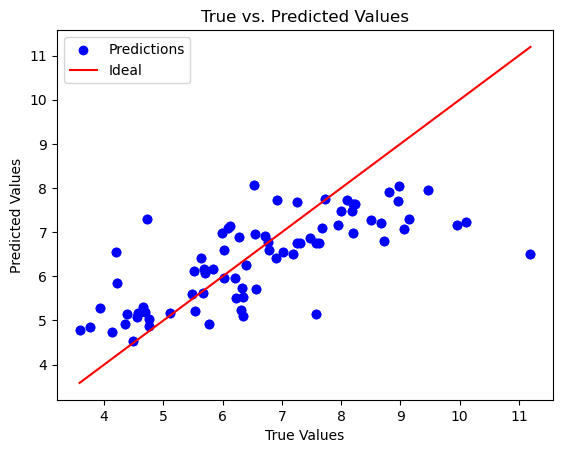

854
606
854
107
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 10
max_resources_: 606
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 60
n_resources: 10
Fitting 5 folds for each of 60 candidates, totalling 300 fits
----------
iter: 1
n_candidates: 20
n_resources: 30
Fitting 5 folds for each of 20 candidates, totalling 100 fits
----------
iter: 2
n_candidates: 7
n_resources: 90
Fitting 5 folds for each of 7 candidates, totalling 35 fits
----------
iter: 3
n_candidates: 3
n_resources: 270
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Mean Squared Error (MSE): 0.9625325788747668
Mean Absolute Error (MAE): 0.7848360603598977
R^2 Score: 0.41761774763951276


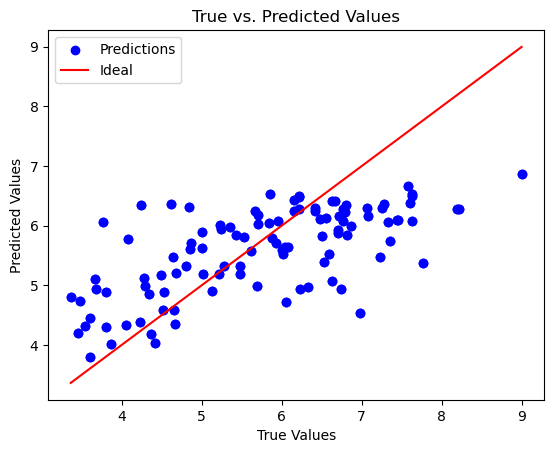

In [ ]:
# Train Cmax models

for column in ["median pMolar unbound plasma concentration" ,
               "median pMolar total plasma concentration"]:
    
    df_subset = cmax_train_data.dropna(subset=[column]).reset_index(drop=True)
    
    y = np.array(df_subset[column])
    features= df_subset.drop(["median pMolar total plasma concentration", 
                "median pMolar unbound plasma concentration", "protonated_Standardized_SMILES"] , axis = 1)

    feature_list = list(features.columns)
    X = np.array(features)
    
    # Split the data into training and test sets with 20% of data being used for testing.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

    print(len(X_train[0]))
    print(len(y_train))
    print(len(X_test[0]))
    print(len(y_test))

    
    # Create the random forest regressor
    rf = RandomForestRegressor(random_state=42)

    # Update the hyperparameter grid
    param_dist_grid = { 
        'max_depth': randint(5, 20),
        'max_features': randint(30, 50),
        'min_samples_leaf': randint(5, 15),
        'min_samples_split': randint(5, 15),
        'n_estimators': [200, 300, 400, 500, 600],
        'bootstrap': [True, False],
        'random_state': [42],
        'criterion': ['squared_error', 'absolute_error'],
        'n_jobs': [30]
    }

    # Using KFold instead of StratifiedKFold for regression
    inner_cv = ShuffleSplit (n_splits=5, test_size=0.2, random_state=42)

    # HalvingRandomSearchCV setup
    rsh = HalvingRandomSearchCV(estimator=rf, param_distributions=param_dist_grid,
                                factor=3, random_state=42, n_jobs=30, verbose=1,
                                cv=inner_cv, min_resources="smallest")

    # Fit the model
    rsh.fit(X_train, y_train)

    # Get the best estimator
    regressor = rsh.best_estimator_
    regressor.fit(X_train, y_train)
    
    


    # Predict on the held-out test set and NCV compounds
    y_pred = regressor.predict(X_test)
    
    # Evaluation metrics for the held-out test set
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("Mean Squared Error (MSE):", mse)
    print("Mean Absolute Error (MAE):", mae)
    print("R^2 Score:", r2)


    plt.scatter(y_test, y_pred, color='blue', label='Predictions')
    # plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Ideal')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Ideal')
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.legend()
    plt.title("True vs. Predicted Values")
    plt.show()
    
    regressor.fit(X, y)
    pickle.dump(regressor, open(f"{model_dir}/bestlivmodel_{column}_model.sav",  'wb'))

In [62]:
# Prepare data for Pred

file = open(f'{data_dir}/features_morgan_mordred_maccs_physc.txt', "r")
file_lines = file.read()
all_features = file_lines.split("\n")
all_features = all_features[:-1]

y_heldouttest = np.array(test_data_heldouttest['TOXICITY'])
test_features= test_data_heldouttest[all_features]

test_feature_list = list(test_features.columns)
X_heldouttest = np.array(test_features)

y_ncv = np.array(test_data_ncv['TOXICITY'])
test_features= test_data_ncv[all_features]

test_feature_list = list(test_features.columns)
X_ncv = np.array(test_features)

In [80]:
# Add Cmax Predictions to Goldstandard

for column in ["unbound" , "total"]:
    
    regressor = pickle.load(open(f"{model_dir}/Cmax_{column}.sav", 'rb'))
    
    #Add predictions to held out test set dili
    y_pred = regressor.predict(X_heldouttest)
    y_pred = y_pred[:,0]
    test_data_heldouttest[column]=y_pred
    
    #Add predictions to NCV compounds  dili
    y_pred = regressor.predict(X_ncv)
    y_pred = y_pred[:,0]
    test_data_ncv[column]=y_pred

In [81]:
# Prep data for second training

y_heldouttest = np.array(test_data_heldouttest['TOXICITY'])
test_features = test_data_heldouttest[["unbound" , "total"]]

test_feature_list = list(test_features.columns)
X_heldouttest = np.array(test_features)

y_ncv = np.array(test_data_ncv['TOXICITY'])
test_features = test_data_ncv[["unbound" , "total"]]

test_feature_list = list(test_features.columns)
X_ncv = np.array(test_features)

In [83]:
# Run second training

df_subset =test_data_ncv
    
y_train = np.array(df_subset['TOXICITY'])
features= df_subset[["unbound" , "total"]]

feature_list = list(features.columns)
X_train = np.array(features)
    
print(len(X_train[0]))
print(len(y_train))
print(len(X_heldouttest[0]))
print(len(y_heldouttest))
    
print('y_train dataset shape %s' % Counter(y_train))
print('y_heldouttest dataset shape %s' % Counter(y_heldouttest))
          
    
#Hyperparameter Optimisation
rf = RandomForestClassifier(n_jobs=-1, random_state=42)
# Instantiate the RandomHalving search model
param_dist_grid = { 
            'max_depth': randint(5, 20),
            'max_features': randint(30, 50),
            'min_samples_leaf': randint(5, 15),
            'min_samples_split': randint(5, 15),
            'n_estimators':[200, 300, 400, 500, 600],
            'bootstrap': [True, False],
            'oob_score': [False],
            'random_state': [42],
            'criterion': ['gini', 'entropy'],
            'n_jobs': [30],
            'class_weight' : [None, 'balanced_subsample', 'balanced']}

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)    
rsh = HalvingRandomSearchCV(estimator=rf, param_distributions=param_dist_grid,
                                factor=2, random_state=42, n_jobs=30, verbose=1, cv = inner_cv)
rsh.fit(X_train, y_train)
classifier = rsh.best_estimator_
classifier.fit(X_train, y_train)

2
888
2
223
y_train dataset shape Counter({1: 570, 0: 318})
y_heldouttest dataset shape Counter({1: 146, 0: 77})
n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 20
max_resources_: 888
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 44
n_resources: 20
Fitting 5 folds for each of 44 candidates, totalling 220 fits
----------
iter: 1
n_candidates: 22
n_resources: 40
Fitting 5 folds for each of 22 candidates, totalling 110 fits
----------
iter: 2
n_candidates: 11
n_resources: 80
Fitting 5 folds for each of 11 candidates, totalling 55 fits
----------
iter: 3
n_candidates: 6
n_resources: 160
Fitting 5 folds for each of 6 candidates, totalling 30 fits
----------
iter: 4
n_candidates: 3
n_resources: 320
Fitting 5 folds for each of 3 candidates, totalling 15 fits
----------
iter: 5
n_candidates: 2
n_resources: 640
Fitting 5 folds for each of 2 candidates, totalling 10 fits


RandomForestClassifier(max_depth=7, max_features=48, min_samples_leaf=7,
                       min_samples_split=8, n_estimators=200, n_jobs=30,
                       random_state=42)

Best Threshold=0.576003
[[ 22  55]
 [ 36 110]]
              precision    recall  f1-score   support

           0       0.38      0.29      0.33        77
           1       0.67      0.75      0.71       146

    accuracy                           0.59       223
   macro avg       0.52      0.52      0.52       223
weighted avg       0.57      0.59      0.58       223

balanced_accuracy_score  0.5195694716242661
matthews_corrcoef  0.04242041541063312
Sensitivity 0.2857142857142857
Specificity 0.7534246575342466
f1 0.7073954983922829
LR+ 1.1587301587301588
ppv 0.6666666666666666
average_precision_score 0.7380583174750537
roc_auc_score 0.5664027753068849


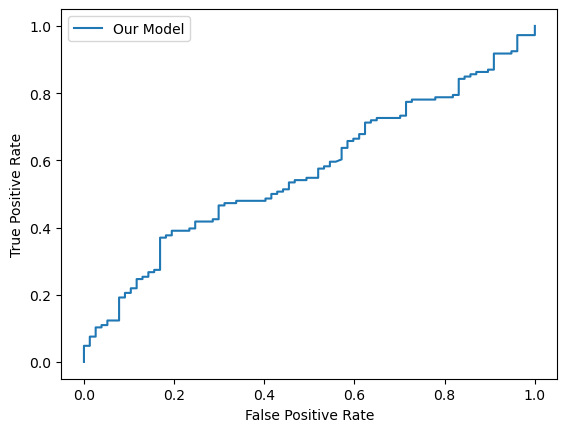

In [84]:
#Add predictions to held out test set dili

y_proba = classifier.predict_proba(X_heldouttest)[:,1]
  
#Add predictions to NCV compounds  dili
y_proba = classifier.predict_proba(X_ncv)[:,1]
    
#Find best threshold using NCV DIlI compounds
cross_val_prob_cp = cross_val_predict(classifier, X_ncv, y_ncv, cv=inner_cv, method='predict_proba', n_jobs=-1)[:, 1]
# calculate roc curves
fpr, tpr, thresholds = roc_curve(y_ncv, cross_val_prob_cp)
# get the best threshold
J = tpr - fpr
ix = argmax(J)
best_thresh = thresholds[ix]
print('Best Threshold=%f' % (best_thresh))
    
#Comapre for held out test set
y_proba = classifier.predict_proba(X_heldouttest)[:,1]
y_pred  = [ 1 if x>best_thresh  else 0 for x in y_proba ]

conf_matrix = confusion_matrix(y_heldouttest, y_pred)
print(conf_matrix)
print(classification_report(y_heldouttest, y_pred))
print('balanced_accuracy_score ',balanced_accuracy_score(y_heldouttest, y_pred))
print('matthews_corrcoef ',matthews_corrcoef(y_heldouttest, y_pred))

# Sensitivity, hit rate, recall, or true positive rate
Sensitivity = conf_matrix[0,0]/(conf_matrix[0,0]+conf_matrix[0,1])
# Specificity or true negative rate
Specificity = conf_matrix[1,1]/(conf_matrix[1,0]+conf_matrix[1,1]) 
f1= f1_score(y_heldouttest, y_pred)
pos_LR = Sensitivity / (1 - Specificity) 
ppv= precision_score(y_heldouttest, y_pred, average='binary')
    
print("Sensitivity", Sensitivity)
print("Specificity", Specificity)
print("f1", f1)
print("LR+", pos_LR)
print("ppv", ppv)
       
print("average_precision_score", average_precision_score(y_heldouttest, y_proba))
    
print("roc_auc_score", roc_auc_score(y_heldouttest, y_proba)) 
# calculate roc curves
best_model_fpr, best_model_tpr, _ = roc_curve(y_heldouttest, y_proba)
# plot the roc curve for the model
plt.plot(best_model_fpr, best_model_tpr, label='Our Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()  

